In [1]:
import sys

import torch

import pandas as pd

import pm4py
from pm4py.visualization.petri_net import visualizer as pn_vis

from config.feature_config import FeatureConfig
from config.ga_config import GAConfig

from utils.general_utils import set_stdout_to_file, set_seed
from utils.feature_utils import df_to_sequence_array

from model.preprocessor import PreprocessorArtifacts

from model.next_event_model import ProcessLSTM
from model.model_wrapper import ModelWrapper

from ga_search.search import CounterfactualGA

from process.engine import ProcessModelConstraintEngine
from process.experimenter import ExperimentHandler

### --- Load Dataset & Models ---

In [2]:
set_seed(seed=42)

In [3]:
df = pd.read_excel(
    "../../data/sepsis.xlsx",
    engine="openpyxl",
    keep_default_na=False,
    dtype={
        "case:concept:name": "string",
        "concept:name": "string",
        "lifecycle:transition": "string",
        "org:group": "string",
        "case:age": "float32",
        "Leucocytes": "float32",
        "CRP": "float32",
    }
)

df["time:timestamp"] = pd.to_datetime(df["time:timestamp"])

In [4]:
df.head(20)

,case:concept:name,time:timestamp,CRP,Leucocytes,case:age,concept:name,lifecycle:transition,org:group,time_delta
0,A,2014-10-22 11:15:41,0.0,0.0,85.0,ER Registration,complete,A,0
1,A,2014-10-22 11:27:00,0.0,9.6,85.0,Leucocytes,complete,B,679
2,A,2014-10-22 11:27:00,21.0,0.0,85.0,CRP,complete,B,0
3,A,2014-10-22 11:27:00,0.0,0.0,85.0,LacticAcid,complete,B,0
4,A,2014-10-22 11:33:37,0.0,0.0,85.0,ER Triage,complete,C,397
5,A,2014-10-22 11:34:00,0.0,0.0,85.0,ER Sepsis Triage,complete,A,23
6,A,2014-10-22 14:03:47,0.0,0.0,85.0,IV Liquid,complete,A,8987
7,A,2014-10-22 14:03:47,0.0,0.0,85.0,IV Antibiotics,complete,A,0
8,A,2014-10-22 14:13:19,0.0,0.0,85.0,Admission NC,complete,D,572
9,A,2014-10-24 09:00:00,109.0,0.0,85.0,CRP,complete,B,154001


In [5]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
device

device(type='cuda')

In [6]:
feature_config = FeatureConfig.load()

In [7]:
feature_config.summary()

  activity_feature:    concept:name
  feature_order:       ['CRP', 'Leucocytes', 'case:age', 'concept:name', 'lifecycle:transition', 'org:group', 'time_delta']
--------------------------------------------------------------------------------------------------------------------------------------
Feature                        Type           Level    Vary   Range/Categories                         MAD        Source              
--------------------------------------------------------------------------------------------------------------------------------------
org:group                      categorical    event    yes    ['A', 'B', 'C', ...]                     N/A        data_derived        
case:age                       continuous     case     yes    [40.00, 90.00]                           10.0000    quantile_derived    
time_delta                     continuous     event    yes    [0.00, 38748.80]                         139.0000   quantile_derived    
Leucocytes                    

In [8]:
preprocessor_artifacts = PreprocessorArtifacts.load()

In [9]:
model = ProcessLSTM.load()

In [10]:
model_wrapper = ModelWrapper(
    model=model,
    preprocessor_artifacts=preprocessor_artifacts,
    device=device
)

### --- Process Constraints ---

In [11]:
net, initial_marking, final_marking = pm4py.discover_petri_net_inductive(
    df,
    noise_threshold=0.5,
    case_id_key='case:concept:name',  
    activity_key='concept:name',
    timestamp_key='time:timestamp'
)

engine = ProcessModelConstraintEngine(
    petri_net=net,
    initial_marking=initial_marking,
    final_marking=final_marking
)
engine.save()

In [12]:
# engine = ProcessModelConstraintEngine.load()

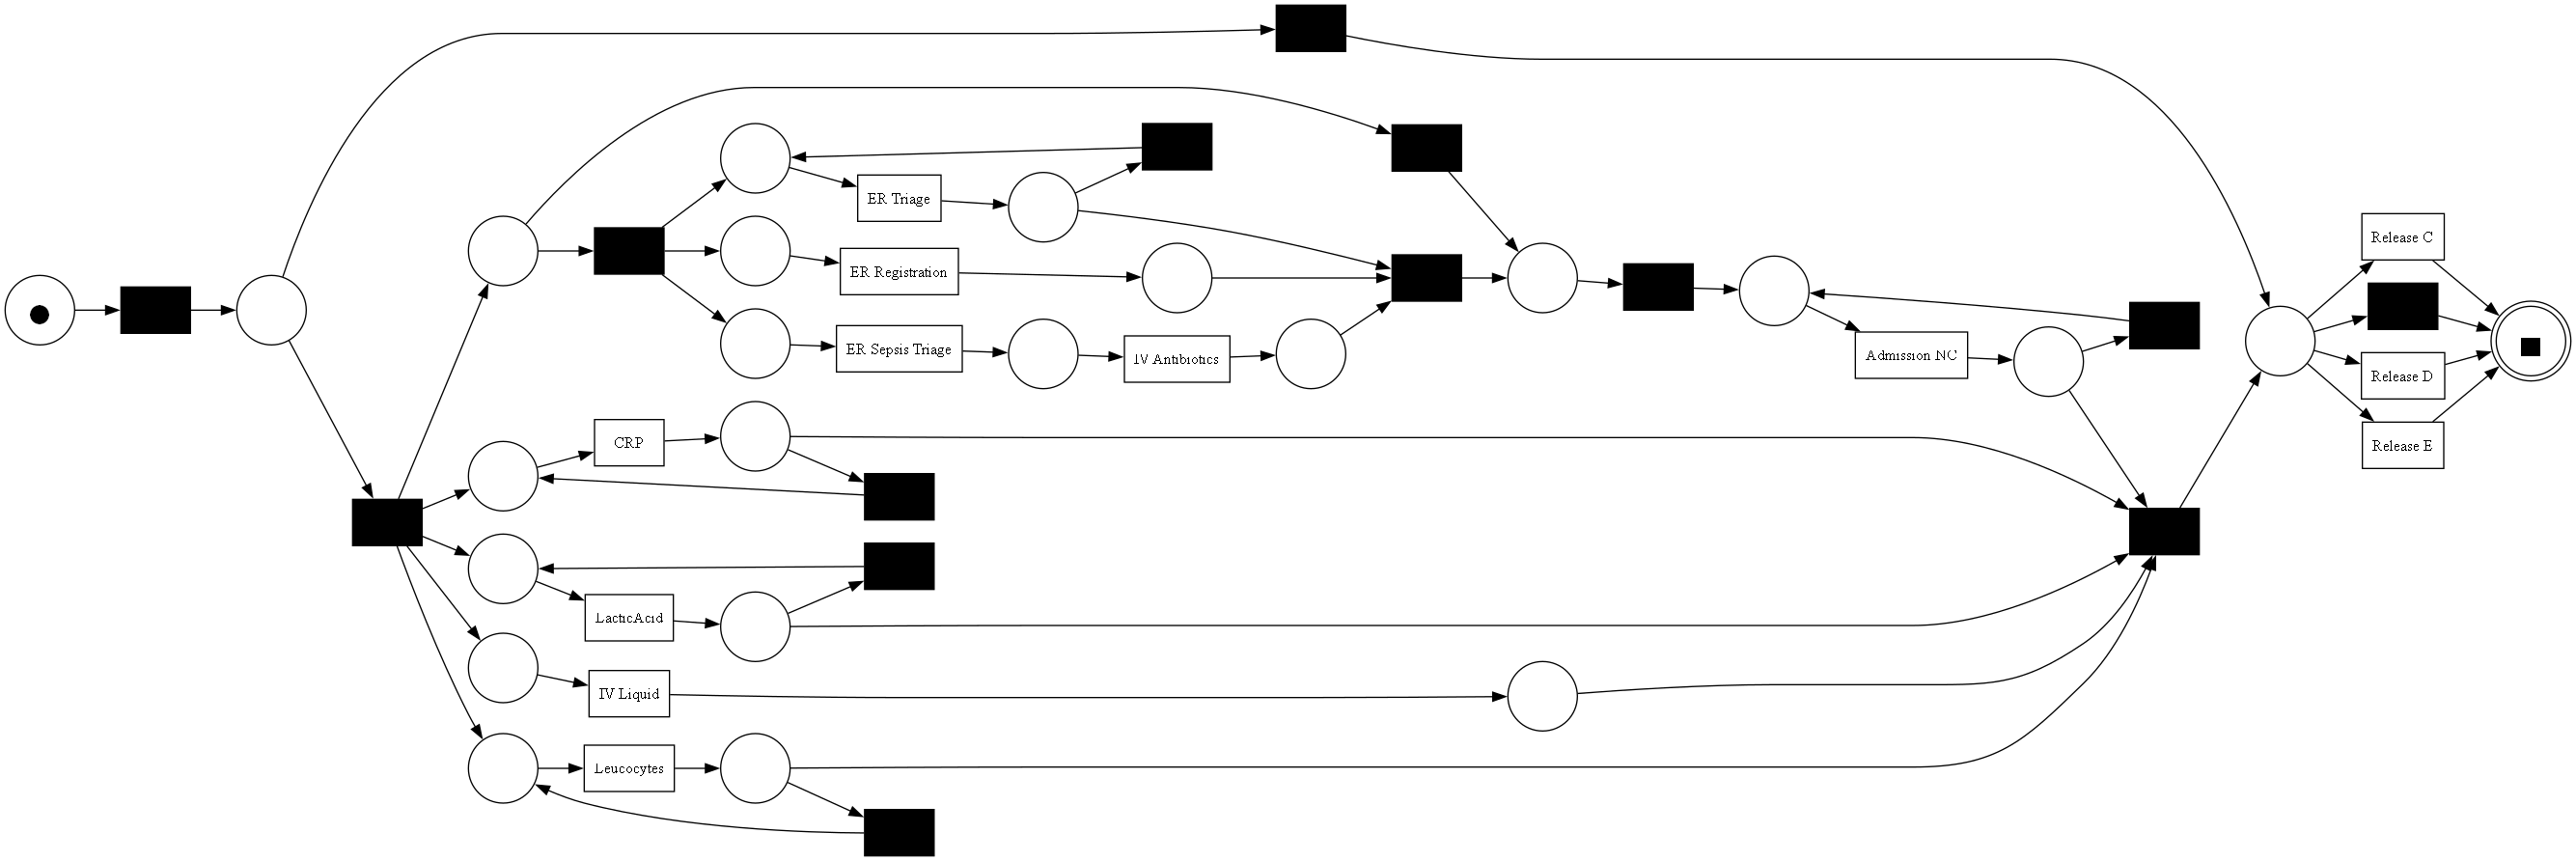

In [13]:
gviz = pn_vis.apply(
    net,
    initial_marking,
    final_marking,
)

pn_vis.view(gviz)

In [14]:
engine.parallel_sets

[{'Admission NC',
  'CRP',
  'ER Registration',
  'ER Sepsis Triage',
  'ER Triage',
  'IV Antibiotics',
  'IV Liquid',
  'LacticAcid',
  'Leucocytes'},
 {'ER Registration', 'ER Sepsis Triage', 'ER Triage', 'IV Antibiotics'}]

In [15]:
engine.branching_sets

[{'Admission NC',
  'CRP',
  'ER Registration',
  'ER Sepsis Triage',
  'ER Triage',
  'IV Antibiotics',
  'IV Liquid',
  'LacticAcid',
  'Leucocytes'},
 {'ER Registration', 'ER Sepsis Triage', 'ER Triage', 'IV Antibiotics'},
 {'Release C', 'Release D', 'Release E'}]

### --- Experiments Generation ---

In [16]:
log_file, original_stdout = set_stdout_to_file(filepath="logs/sepsis-cf_generated_experiments_ga_output.txt", console=False)

In [17]:
generator = ExperimentHandler(
    constraint_engine=engine,
)

In [18]:
exp_df_sin = generator.generate_experiments_from_log(
    df=df,
    case_id_field="case:concept:name",
    activity_field="concept:name",
    sort_field="time:timestamp",
    save_path="experiments/cf_generated_experiments_single_desired",
    min_desired=1,
    max_desired=1,
)

In [19]:
exp_df_mul = generator.generate_experiments_from_log(
    df=df,
    case_id_field="case:concept:name",
    activity_field="concept:name",
    sort_field="time:timestamp",
    save_path="experiments/cf_generated_experiments_multiple_desired",
    min_desired=2,
)

In [20]:
max(exp_df_sin['num_desired'])

1

In [21]:
len(exp_df_sin)

190

In [22]:
exp_df_sin.head()

,template_id,case:concept:name,trace_length,start_pos,length,num_desired,source_pattern,target_pattern,desired_positions,source_support,target_support,num_cases_for_template,experiment_type
0,0,FFA,3,0,3,1,"(ER Registration, ER Triage, ER Sepsis Triage)","(ER Registration, ER Triage, CRP)",{2: {'CRP'}},808,43,10,window_variant_mixed
1,0,CL,4,0,3,1,"(ER Registration, ER Triage, ER Sepsis Triage)","(ER Registration, ER Triage, CRP)",{2: {'CRP'}},808,43,10,window_variant_mixed
2,0,KY,5,0,3,1,"(ER Registration, ER Triage, ER Sepsis Triage)","(ER Registration, ER Triage, CRP)",{2: {'CRP'}},808,43,10,window_variant_mixed
3,0,FP,6,0,3,1,"(ER Registration, ER Triage, ER Sepsis Triage)","(ER Registration, ER Triage, CRP)",{2: {'CRP'}},808,43,10,window_variant_mixed
4,0,GIA,7,0,3,1,"(ER Registration, ER Triage, ER Sepsis Triage)","(ER Registration, ER Triage, CRP)",{2: {'CRP'}},808,43,10,window_variant_mixed


In [23]:
min(exp_df_mul['num_desired'])

2

In [24]:
max(exp_df_mul['num_desired'])

3

In [25]:
len(exp_df_mul)

60

In [26]:
exp_df_mul.head()

,template_id,case:concept:name,trace_length,start_pos,length,num_desired,source_pattern,target_pattern,desired_positions,source_support,target_support,num_cases_for_template,experiment_type
0,0,KGA,6,3,3,2,"(Leucocytes, CRP, Admission NC)","(IV Liquid, IV Antibiotics, Leucocytes)","{3: {'IV Liquid'}, 4: {'IV Antibiotics'}}",25,35,10,window_variant_mixed
1,0,FC,7,3,3,2,"(Leucocytes, CRP, Admission NC)","(IV Liquid, IV Antibiotics, Leucocytes)","{3: {'IV Liquid'}, 4: {'IV Antibiotics'}}",25,35,10,window_variant_mixed
2,0,GDA,8,3,3,2,"(Leucocytes, CRP, Admission NC)","(IV Liquid, IV Antibiotics, Leucocytes)","{3: {'IV Liquid'}, 4: {'IV Antibiotics'}}",25,35,10,window_variant_mixed
3,0,RHA,9,3,3,2,"(Leucocytes, CRP, Admission NC)","(IV Liquid, IV Antibiotics, Leucocytes)","{3: {'IV Liquid'}, 4: {'IV Antibiotics'}}",25,35,10,window_variant_mixed
4,0,YW,10,3,3,2,"(Leucocytes, CRP, Admission NC)","(IV Liquid, IV Antibiotics, Leucocytes)","{3: {'IV Liquid'}, 4: {'IV Antibiotics'}}",25,35,10,window_variant_mixed


In [27]:
# exp_df_sin, metadata_sin = ExperimentHandler.load("experiments/cf_generated_experiments_single_desired")
# print("Mined using parameters:", metadata_sin["parameters"])

# exp_df_mul, metadata_mul = ExperimentHandler.load("experiments/cf_generated_experiments_multiple_desired")
# print("Mined using parameters:", metadata_mul["parameters"])

### --- Counterfactuals ---

In [28]:
ga_config = GAConfig(
    w_distance=1.0,
    w_sparsity=1.0,
    w_margin=1.0,
    w_process_violation=1.0,
)
ga_config.validate()

cf_GA = CounterfactualGA(
    ga_config=ga_config,
    feature_config=feature_config,
    model_wrapper=model_wrapper
)

In [29]:
results_sin = generator.run_experiment_df(
    cf_method=cf_GA,
    technique="GA_single_desired",
    exp_df=exp_df_sin,
    df=df,
    feature_config=feature_config,
    case_id_field="case:concept:name",
    sort_field="time:timestamp",
)

Experiments:   0%|          | 0/190 [00:00<?, ?case/s]

In [30]:
results_sin

,template_id,case:concept:name,trace_length,num_desired,num_flexible,DISTANCE,CONT_DISTANCE,CAT_DISTANCE,SPARSITY,PROCESS_VIOLATION,...,best_cf_fitness,best_cf_process_violation,best_cf_distance,best_cf_cat_distance,best_cf_cont_distance,best_cf_sparsity,best_cf_margin_loss,best_cf_margin_loss_na,best_cf_margin_loss_flipped,best_cf_margin_loss_na_flipped
0,0,FFA,3,1,3,0.621091,0.392182,0.850000,0.588889,0.000000,...,0.497449,0.000000,0.275227,0.500000,0.050454,0.222222,0.0,0.000000,0.0,0.000000
1,0,CL,4,1,4,0.404070,0.208140,0.600000,0.472222,0.181818,...,0.773516,0.181818,0.258364,0.500000,0.016728,0.333333,0.0,0.000000,0.0,0.000000
2,0,KY,5,1,5,0.499297,0.173594,0.825000,0.394444,0.307692,...,0.668803,0.307692,0.250000,0.500000,0.000000,0.111111,0.0,0.887689,0.0,1.000000
3,0,FP,6,1,6,0.353240,0.131481,0.575000,0.344444,0.400000,...,0.761111,0.400000,0.250000,0.500000,0.000000,0.111111,0.0,0.887878,0.0,1.000000
4,0,GIA,7,1,7,0.445662,0.216325,0.675000,0.416667,0.276471,...,0.717901,0.235294,0.260385,0.500000,0.020770,0.222222,0.0,0.000000,0.0,0.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
162,18,MFA,12,1,11,0.376673,0.253346,0.500000,0.514444,0.307407,...,0.320973,0.000000,0.120973,0.090909,0.151037,0.200000,0.0,0.709889,0.0,0.999999
163,18,OKA,12,1,11,0.350152,0.195759,0.504545,0.482222,0.331481,...,0.396071,0.185185,0.099775,0.090909,0.108640,0.111111,0.0,0.671623,0.0,0.999999
164,18,SS,12,1,11,0.359581,0.210072,0.509091,0.446667,0.325926,...,0.414113,0.185185,0.095595,0.090909,0.100281,0.133333,0.0,0.814184,0.0,1.000000
165,18,ZFA,12,1,11,0.309823,0.192373,0.427273,0.433333,0.366667,...,0.473636,0.259259,0.081043,0.090909,0.071178,0.133333,0.0,0.733332,0.0,0.999999


In [31]:
results_mul = generator.run_experiment_df(
    cf_method=cf_GA,
    technique="GA_multiple_desired",
    exp_df=exp_df_mul,
    df=df,
    feature_config=feature_config,
    case_id_field="case:concept:name",
    sort_field="time:timestamp",
)

Experiments:   0%|          | 0/60 [00:00<?, ?case/s]

In [32]:
results_mul

,template_id,case:concept:name,trace_length,num_desired,num_flexible,DISTANCE,CONT_DISTANCE,CAT_DISTANCE,SPARSITY,PROCESS_VIOLATION,...,best_cf_fitness,best_cf_process_violation,best_cf_distance,best_cf_cat_distance,best_cf_cont_distance,best_cf_sparsity,best_cf_margin_loss,best_cf_margin_loss_na,best_cf_margin_loss_flipped,best_cf_margin_loss_na_flipped
0,0,KGA,6,2,6,0.459632,0.169264,0.750000,0.430769,0.583333,...,0.632479,0.388889,0.166667,0.333333,0.000000,0.076923,0.000000,0.466870,0.000000,0.500000
1,0,FC,7,2,6,0.401175,0.102350,0.700000,0.346154,0.607500,...,0.773219,0.450000,0.169373,0.333333,0.005412,0.153846,0.000000,0.465873,0.000000,0.500000
2,0,GDA,8,2,7,0.468289,0.086578,0.850000,0.380769,0.556818,...,0.825963,0.500000,0.172117,0.333333,0.010901,0.153846,0.000000,0.466973,0.000000,0.500000
3,0,RHA,9,2,8,0.379409,0.075485,0.683333,0.296154,0.685417,...,0.785256,0.541667,0.166667,0.333333,0.000000,0.076923,0.000000,0.470701,0.000000,0.500000
4,0,YW,10,2,9,0.355401,0.144135,0.566667,0.334615,0.669231,...,0.962360,0.576923,0.167860,0.333333,0.002386,0.153846,0.063731,0.530749,0.000000,0.500000
5,0,GMA,13,2,12,0.448916,0.147833,0.750000,0.396154,0.776563,...,1.049471,0.187500,0.005450,0.000000,0.010901,0.076923,0.779598,0.779598,0.999999,0.999999
6,0,TIA,15,2,14,0.424004,0.098008,0.750000,0.334615,0.815278,...,1.014964,0.694444,0.166673,0.333333,0.000013,0.153846,0.000000,0.467378,0.000000,0.500000
7,0,GS,16,2,15,0.467266,0.167865,0.766667,0.403846,0.790789,...,1.046705,0.315789,0.000000,0.000000,0.000000,0.000000,0.730915,0.730915,0.999996,0.999996
8,0,GG,17,2,16,0.396755,0.093510,0.700000,0.346154,0.828750,...,1.055178,0.725000,0.176332,0.333333,0.019331,0.153846,0.000000,0.467035,0.000000,0.500000
9,0,XFA,18,2,16,0.423439,0.080211,0.766667,0.342308,0.816667,...,0.934066,0.690476,0.166667,0.333333,0.000000,0.076923,0.000000,0.471234,0.000000,0.500000


### --- Cleanup ---

In [33]:
sys.stdout = original_stdout
log_file.close()